# CLIP Never Forgets
**Frozen VLM Feature는 그 자체로 강력한 클래스 증분 학습 Baseline이다**

Frozen CLIP ViT-B/32로 CIFAR-100 클래스 증분 학습(CIL, 10 tasks × 10 classes)을 수행하고,
동일한 backbone을 공유하는 세 가지 분류 방식을 비교한다.
핵심 질문: catastrophic forgetting은 정확히 어디서 오는가?

- **Zero-shot CLIP** — 텍스트 프롬프트 분류기, 학습 없음
- **Prototype (NCM)** — few-shot 이미지 임베딩의 클래스별 평균으로 분류, head 갱신 없음
- **Sequential Linear Probe** — linear head를 task마다 이어서 fine-tuning (replay 없음)

**TL;DR:** Frozen representation은 잊지 않는다 — 붕괴는 전적으로 classifier head의 recency bias에서 온다.

실행 환경: Google Colab (T4)

## 1. 환경 세팅
의존성 설치, CLIP ViT-B/32 로드, CIFAR-100 train/test 전체 이미지의 L2 정규화 임베딩을 한 번만 추출한다.

In [1]:
!pip install -q ftfy regex tqdm
!pip install -q git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import clip
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import CIFAR100
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import json, random

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()
print("CLIP loaded on", device)

100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 77.7MiB/s]


CLIP loaded on cuda


In [3]:
train_set = CIFAR100(root="./data", train=True, download=True, transform=preprocess)
test_set  = CIFAR100(root="./data", train=False, download=True, transform=preprocess)
class_names = [c.replace("_", " ") for c in train_set.classes]

@torch.no_grad()
def extract_embeddings(dataset, batch_size=512):
    loader = DataLoader(dataset, batch_size=batch_size, num_workers=2)
    feats, labels = [], []
    for x, y in tqdm(loader):
        f = model.encode_image(x.to(device))
        f = f / f.norm(dim=-1, keepdim=True)
        feats.append(f.cpu()); labels.append(y)
    return torch.cat(feats).float(), torch.cat(labels)

train_feats, train_labels = extract_embeddings(train_set)
test_feats,  test_labels  = extract_embeddings(test_set)

torch.save({"train_feats": train_feats, "train_labels": train_labels,
            "test_feats": test_feats, "test_labels": test_labels}, "cifar100_clip_vitb32.pt")
print(train_feats.shape, test_feats.shape)

100%|██████████| 169M/169M [1:11:39<00:00, 39.3kB/s]
100%|██████████| 20/20 [00:20<00:00,  1.00s/it]


torch.Size([50000, 512]) torch.Size([10000, 512])


## 2. 증분 학습 프로토콜
CIFAR-100을 **10 tasks × 10 classes**로 분할한다 (클래스 순서는 고정 시드로 셔플).
각 클래스에서 학습용으로 **16장**(few-shot)만 샘플링하고, 평가는 test set 전체를 사용한다.

In [4]:
NUM_TASKS = 10
CLASSES_PER_TASK = 10
SHOTS = 16  # 클래스당 few-shot 개수

rng = np.random.RandomState(SEED)
class_order = rng.permutation(100)
tasks = [class_order[i*CLASSES_PER_TASK:(i+1)*CLASSES_PER_TASK] for i in range(NUM_TASKS)]

fewshot_idx = {}
for c in range(100):
    idx = np.where(train_labels.numpy() == c)[0]
    fewshot_idx[c] = rng.choice(idx, SHOTS, replace=False)

for t, cls in enumerate(tasks[:3]):
    print(f"Task {t}: classes {sorted(cls.tolist())}")

Task 0: classes [0, 10, 22, 39, 44, 45, 53, 70, 80, 83]
Task 1: classes [4, 12, 18, 30, 31, 33, 73, 76, 77, 90]
Task 2: classes [9, 15, 26, 40, 42, 55, 69, 72, 88, 96]


## 3. 비교 방법
세 분류기 모두 동일한 frozen CLIP feature를 공유한다.

샘플은 항상 자기 task 내부(10-way)가 아니라 지금까지 등장한 전체 클래스 중에서 분류된다.
이 선택이 결론을 좌우한다 — 모든 task 학습이 끝난 최종 linear probe로 Task-1을 평가하면:

- **10-way** (task 내부 후보만): **0.848**
- **100-way** (전체 클래스 후보): **0.000**

즉 Task-1 클래스들을 구분하는 능력은 끝까지 온전히 남아 있다. 무너지는 것은 과거 클래스와
최신 클래스가 후보로 경쟁할 때뿐이다 — forgetting처럼 보이는 현상의 정체는 head의 recency bias다.
(검증 코드는 5번 섹션 셀.)

In [5]:
@torch.no_grad()
def get_text_embeddings(names):
    prompts = clip.tokenize([f"a photo of a {n}" for n in names]).to(device)
    t = model.encode_text(prompts)
    return (t / t.norm(dim=-1, keepdim=True)).cpu().float()

text_embs = get_text_embeddings(class_names)

def _get_subset(target_cls):
    """평가 대상 클래스(target_cls)에 속한 test 샘플만 추출"""
    tgt = torch.tensor(sorted(target_cls))
    mask = torch.isin(test_labels, tgt)
    return test_feats[mask], test_labels[mask]

def eval_zeroshot(target_cls, seen):
    """target_cls 샘플을 '전체 seen 클래스' 후보 중에서 분류"""
    feats, labels = _get_subset(target_cls)
    seen = torch.tensor(sorted(seen))
    logits = feats @ text_embs[seen].T
    pred = seen[logits.argmax(dim=1)]
    return (pred == labels).float().mean().item()

print("Zero-shot (전체 100 클래스):", eval_zeroshot(list(range(100)), list(range(100))))

Zero-shot (전체 100 클래스): 0.6419000029563904


In [6]:
def build_prototype(c):
    f = train_feats[fewshot_idx[c]]
    p = f.mean(dim=0)
    return p / p.norm()

prototypes = torch.zeros(100, train_feats.shape[1])

def eval_prototype(target_cls, seen):
    """target_cls 샘플을 '전체 seen 클래스' 후보 중에서 분류"""
    feats, labels = _get_subset(target_cls)
    seen = torch.tensor(sorted(seen))
    logits = feats @ prototypes[seen].T
    pred = seen[logits.argmax(dim=1)]
    return (pred == labels).float().mean().item()

In [7]:
def train_linear_probe(head, task_classes, epochs=100, lr=1e-2):
    """현재 task의 few-shot 데이터'만'으로 head를 이어서 학습 (replay 없음)"""
    idx = np.concatenate([fewshot_idx[c] for c in task_classes])
    x = train_feats[idx].to(device)
    y = train_labels[idx].to(device)
    opt = torch.optim.Adam(head.parameters(), lr=lr)
    head.train()
    for _ in range(epochs):
        opt.zero_grad()
        loss = F.cross_entropy(head(x), y)
        loss.backward(); opt.step()
    return head

@torch.no_grad()
def eval_linear_probe(head, target_cls, seen):
    feats, labels = _get_subset(target_cls)
    seen_t = torch.tensor(sorted(seen))
    logits = head(feats.to(device)).cpu()
    full_mask = torch.full((100,), float("-inf"))
    full_mask[seen_t] = 0
    pred = (logits + full_mask).argmax(dim=1)
    return (pred == labels).float().mean().item()

## 4. 메인 실험
10개 task를 순차적으로 학습한다. 각 task 종료 시점마다
과거 각 task에 대한 정확도를 구하고 전체 seen 클래스에 대한 평균 정확도를 기록한다.

In [8]:
methods = ["zeroshot", "prototype", "linear_probe"]
acc_matrix = {m: np.full((NUM_TASKS, NUM_TASKS), np.nan) for m in methods}
avg_acc = {m: [] for m in methods}

head = nn.Linear(train_feats.shape[1], 100).to(device)
prototypes = torch.zeros(100, train_feats.shape[1])

seen = []
for t in range(NUM_TASKS):
    task_cls = tasks[t].tolist()
    seen += task_cls

    for c in task_cls:
        prototypes[c] = build_prototype(c)
    head = train_linear_probe(head, task_cls)

    # task tau 샘플을 '전체 seen 클래스' 중에서 분류
    for tau in range(t + 1):
        tau_cls = tasks[tau].tolist()
        acc_matrix["zeroshot"][t, tau]     = eval_zeroshot(tau_cls, seen)
        acc_matrix["prototype"][t, tau]    = eval_prototype(tau_cls, seen)
        acc_matrix["linear_probe"][t, tau] = eval_linear_probe(head, tau_cls, seen)

    avg_acc["zeroshot"].append(eval_zeroshot(seen, seen))
    avg_acc["prototype"].append(eval_prototype(seen, seen))
    avg_acc["linear_probe"].append(eval_linear_probe(head, seen, seen))

    print(f"[Task {t+1}/{NUM_TASKS}] avg acc — "
          f"zs: {avg_acc['zeroshot'][-1]:.3f} | "
          f"proto: {avg_acc['prototype'][-1]:.3f} | "
          f"linear_probe: {avg_acc['linear_probe'][-1]:.3f}")

[Task 1/10] avg acc — zs: 0.835 | proto: 0.783 | linear_probe: 0.836
[Task 2/10] avg acc — zs: 0.816 | proto: 0.750 | linear_probe: 0.497
[Task 3/10] avg acc — zs: 0.750 | proto: 0.686 | linear_probe: 0.306
[Task 4/10] avg acc — zs: 0.736 | proto: 0.680 | linear_probe: 0.231
[Task 5/10] avg acc — zs: 0.710 | proto: 0.663 | linear_probe: 0.236
[Task 6/10] avg acc — zs: 0.701 | proto: 0.646 | linear_probe: 0.196
[Task 7/10] avg acc — zs: 0.684 | proto: 0.637 | linear_probe: 0.165
[Task 8/10] avg acc — zs: 0.667 | proto: 0.629 | linear_probe: 0.140
[Task 9/10] avg acc — zs: 0.658 | proto: 0.618 | linear_probe: 0.134
[Task 10/10] avg acc — zs: 0.642 | proto: 0.611 | linear_probe: 0.118


## 5. 결과
**Forgetting measure** = 과거 task별 (역대 최고 정확도 − 최종 정확도)의 평균.

핵심 관찰:
1. **Seq. linear probe는 붕괴한다** (최종 avg acc ~0.12, Task-1 정확도는 세 task 만에 0).
   head가 최신 클래스로만 예측을 몰아버리는 *recency bias*이지, representation의 실패가 아니다.
2. **Prototype (NCM)은 거의 잊지 않는다** (forgetting ~0.09, 클래스당 16장만 사용).
   완만한 하락은 zero-shot과 같은 기울기 — forgetting이 아니라 후보 클래스 증가에 따른 자연스러운 난이도 상승이다.
3. Zero-shot 텍스트 프롬프트는 끝까지 강한 baseline으로 남는다.

In [9]:
def forgetting_measure(A):
    T = A.shape[0]
    f = [np.nanmax(A[:T-1, tau]) - A[T-1, tau] for tau in range(T-1)]
    return float(np.mean(f))

results = {}
for m in methods:
    results[m] = {
        "final_avg_acc": avg_acc[m][-1],
        "forgetting": forgetting_measure(acc_matrix[m]),
    }
print(json.dumps(results, indent=2))

{
  "zeroshot": {
    "final_avg_acc": 0.6419000029563904,
    "forgetting": 0.11755555205874973
  },
  "prototype": {
    "final_avg_acc": 0.6108999848365784,
    "forgetting": 0.09611110554801093
  },
  "linear_probe": {
    "final_avg_acc": 0.11760000139474869,
    "forgetting": 0.8442222256627347
  }
}


In [10]:
# 같은 head라도 10-way(task 내부)로 평가하면 forgetting이 가려진다
@torch.no_grad()
def eval_linear_probe_within_task(head, target_cls):
    """target_cls 샘플을 해당 task의 10개 클래스 안에서만 분류 (10-way)"""
    feats, labels = _get_subset(target_cls)
    tgt = torch.tensor(sorted(target_cls))
    logits = head(feats.to(device)).cpu()
    mask = torch.full((100,), float("-inf"))
    mask[tgt] = 0
    pred = (logits + mask).argmax(dim=1)
    return (pred == labels).float().mean().item()

# 모든 task 학습이 끝난 최종 head로 Task-1을 두 방식으로 평가
task1_cls = tasks[0].tolist()
acc_10way  = eval_linear_probe_within_task(head, task1_cls)
acc_100way = eval_linear_probe(head, task1_cls, list(range(100)))

print(f"Task-1 accuracy (최종 head 기준)")
print(f"  10-way  (task 내부 후보만): {acc_10way:.3f}")
print(f"  100-way (전체 seen 후보):   {acc_100way:.3f}")

Task-1 accuracy (최종 head 기준)
  10-way  (task 내부 후보만): 0.844
  100-way (전체 seen 후보):   0.000


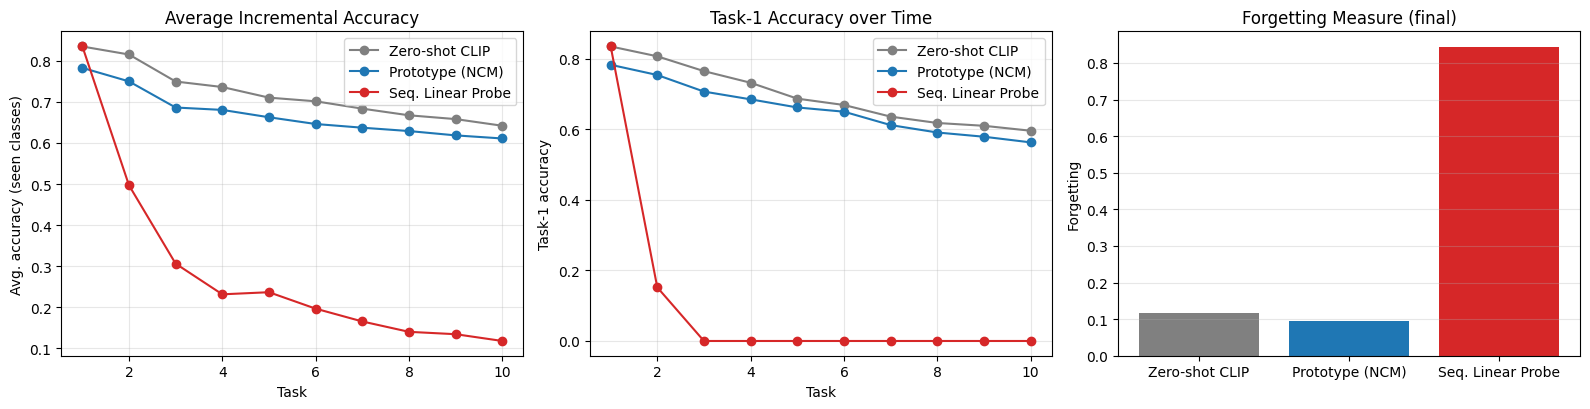

In [11]:
colors = {"zeroshot": "gray", "prototype": "tab:blue", "linear_probe": "tab:red"}
labels = {"zeroshot": "Zero-shot CLIP", "prototype": "Prototype (NCM)", "linear_probe": "Seq. Linear Probe"}
x = np.arange(1, NUM_TASKS + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# (1) Average accuracy 곡선
for m in methods:
    axes[0].plot(x, avg_acc[m], marker="o", color=colors[m], label=labels[m])
axes[0].set_xlabel("Task"); axes[0].set_ylabel("Avg. accuracy (seen classes)")
axes[0].set_title("Average Incremental Accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)

# (2) Task 1 정확도 추적 (forgetting 직관)
for m in methods:
    axes[1].plot(x, acc_matrix[m][:, 0], marker="o", color=colors[m], label=labels[m])
axes[1].set_xlabel("Task"); axes[1].set_ylabel("Task-1 accuracy")
axes[1].set_title("Task-1 Accuracy over Time"); axes[1].legend(); axes[1].grid(alpha=0.3)

# (3) 최종 forgetting 막대그래프
fvals = [results[m]["forgetting"] for m in methods]
axes[2].bar([labels[m] for m in methods], fvals, color=[colors[m] for m in methods])
axes[2].set_ylabel("Forgetting"); axes[2].set_title("Forgetting Measure (final)")
axes[2].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("results.png", dpi=150)
plt.show()

## 6. Ablation: 프로토타입에는 몇 장이 필요한가?
클래스당 shot 수(1/2/4/8/16)에 따른 프로토타입 정확도. **샘플링 시드 3개** 평균 (±std 표시).
정확도는 shot 수에 log-linear하게 증가하지만, 16-shot(0.605)조차 zero-shot 텍스트 프롬프트(0.642)를 넘지 못한다 —
이 세팅에서는 텍스트 임베딩 한 줄이 클래스당 이미지 16장보다 강하다.

In [12]:
SHOT_LIST = [1, 2, 4, 8, 16]
NUM_SEEDS = 3  # 1-shot은 어떤 이미지가 뽑히냐에 따라 편차가 커서 시드 평균 필수

ablation_curves = {}  # {shots: [seed별 avg_acc 곡선]}

for shots in SHOT_LIST:
    curves = []
    for seed in range(NUM_SEEDS):
        rng_ab = np.random.RandomState(1000 + seed)

        # 이 shot 수만큼 few-shot 인덱스 재샘플링
        fs_idx = {}
        for c in range(100):
            idx = np.where(train_labels.numpy() == c)[0]
            fs_idx[c] = rng_ab.choice(idx, shots, replace=False)

        # 프로토타입 증분 루프 (task 분할은 기존 tasks 그대로 사용)
        protos = torch.zeros(100, train_feats.shape[1])
        curve, seen_ab = [], []
        for t in range(NUM_TASKS):
            task_cls = tasks[t].tolist()
            seen_ab += task_cls
            for c in task_cls:
                f = train_feats[fs_idx[c]]
                p = f.mean(dim=0)
                protos[c] = p / p.norm()

            # seen 전체에 대한 avg acc
            seen_t = torch.tensor(sorted(seen_ab))
            mask = torch.isin(test_labels, seen_t)
            feats, labels = test_feats[mask], test_labels[mask]
            pred = seen_t[(feats @ protos[seen_t].T).argmax(dim=1)]
            curve.append((pred == labels).float().mean().item())
        curves.append(curve)
    ablation_curves[shots] = np.array(curves)  # [NUM_SEEDS, NUM_TASKS]
    m = ablation_curves[shots][:, -1]
    print(f"{shots:>2}-shot | final avg acc: {m.mean():.3f} ± {m.std():.3f}")

 1-shot | final avg acc: 0.286 ± 0.015
 2-shot | final avg acc: 0.397 ± 0.003
 4-shot | final avg acc: 0.499 ± 0.004
 8-shot | final avg acc: 0.562 ± 0.004
16-shot | final avg acc: 0.605 ± 0.005


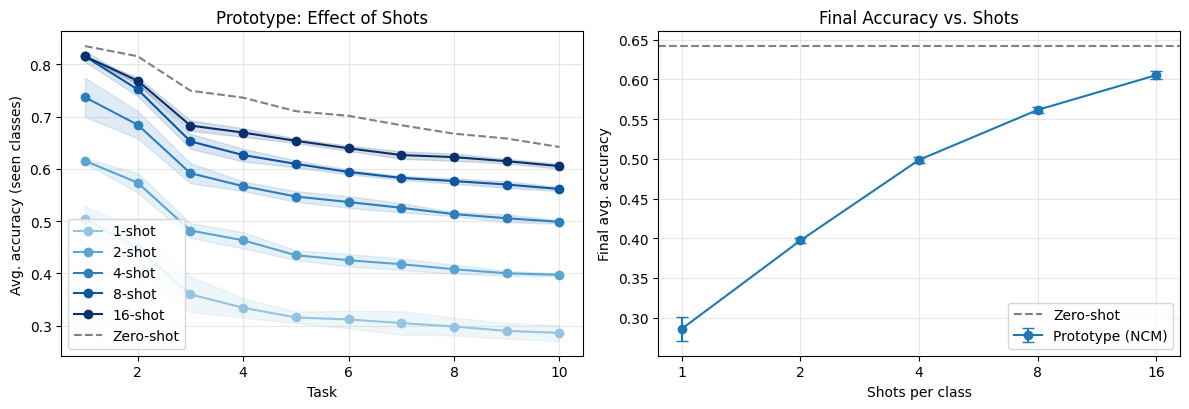

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
cmap = plt.cm.Blues(np.linspace(0.4, 1.0, len(SHOT_LIST)))

# (1) shot별 avg acc 곡선 (시드 평균 ± std)
zs_curve = avg_acc["zeroshot"]
for i, shots in enumerate(SHOT_LIST):
    mean = ablation_curves[shots].mean(axis=0)
    std  = ablation_curves[shots].std(axis=0)
    axes[0].plot(x, mean, marker="o", color=cmap[i], label=f"{shots}-shot")
    axes[0].fill_between(x, mean - std, mean + std, color=cmap[i], alpha=0.15)
axes[0].plot(x, zs_curve, "--", color="gray", label="Zero-shot")
axes[0].set_xlabel("Task"); axes[0].set_ylabel("Avg. accuracy (seen classes)")
axes[0].set_title("Prototype: Effect of Shots"); axes[0].legend(); axes[0].grid(alpha=0.3)

# (2) 최종 정확도 vs shots
finals_mean = [ablation_curves[s][:, -1].mean() for s in SHOT_LIST]
finals_std  = [ablation_curves[s][:, -1].std()  for s in SHOT_LIST]
axes[1].errorbar(SHOT_LIST, finals_mean, yerr=finals_std, marker="o", color="tab:blue",
                 capsize=4, label="Prototype (NCM)")
axes[1].axhline(zs_curve[-1], ls="--", color="gray", label="Zero-shot")
axes[1].set_xscale("log", base=2); axes[1].set_xticks(SHOT_LIST); axes[1].set_xticklabels(SHOT_LIST)
axes[1].set_xlabel("Shots per class"); axes[1].set_ylabel("Final avg. accuracy")
axes[1].set_title("Final Accuracy vs. Shots"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("ablation_shots.png", dpi=150)
plt.show()

## 7. 텍스트–이미지 앙상블
텍스트 프롬프트와 이미지 프로토타입이 각자 잘 작동한다면, 둘은 상보적일까?
정규화된 볼록 결합 `α · text + (1−α) · prototype`으로 분류한다.

| α | 0.0 | 0.25 | **0.5** | 0.75 | 1.0 |
|---|-----|------|---------|------|-----|
| 최종 avg acc | 0.611 | 0.662 | **0.692** | 0.686 | 0.642 |

α = 0.5가 양 끝점을 모두 뚜렷하게 능가한다 -> 두 모달리티는 **상보적 정보**를 담고 있다.
(α = 0과 α = 1이 각각 프로토타입/zero-shot 결과와 정확히 일치 — 구현의 sanity check도 겸한다.)

In [14]:
ALPHA = 0.5  # 텍스트 가중치

def eval_ensemble(target_cls, seen, alpha=ALPHA):
    feats, labels = _get_subset(target_cls)
    seen = torch.tensor(sorted(seen))
    combo = alpha * text_embs[seen] + (1 - alpha) * prototypes[seen]
    combo = combo / combo.norm(dim=-1, keepdim=True)
    pred = seen[(feats @ combo.T).argmax(dim=1)]
    return (pred == labels).float().mean().item()

# 16-shot 프로토타입(기존 prototypes)이 채워진 상태에서 실행
all_cls = list(range(100))
for a in [0.0, 0.25, 0.5, 0.75, 1.0]:
    print(f"alpha={a:.2f} | final avg acc: {eval_ensemble(all_cls, all_cls, a):.3f}")

alpha=0.00 | final avg acc: 0.611
alpha=0.25 | final avg acc: 0.662
alpha=0.50 | final avg acc: 0.692
alpha=0.75 | final avg acc: 0.686
alpha=1.00 | final avg acc: 0.642
